In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import rfft, rfftfreq

g = 9.81  # m/s²

In [7]:
df = pd.read_csv('imuLogPendulumTest1.csv')
df['time'] = pd.to_datetime(df['Timestamp'], format='%Y/%m/%d %H:%M:%S.%f')
df['t_s']  = (df['time'] - df['time'].iloc[0]).dt.total_seconds()

# Convert accelerations from milli-g to m/s²
df['AccX'] = df['AccX'] / 1000 * g
df['AccY'] = df['AccY'] / 1000 * g
df['AccZ'] = df['AccZ'] / 1000 * g

fs = 1.0 / np.median(np.diff(df['t_s'].values))
print(f'Sample rate: {fs:.2f} Hz,  Duration: {df.t_s.iloc[-1]:.1f} s')

Sample rate: 10.00 Hz,  Duration: 132.0 s


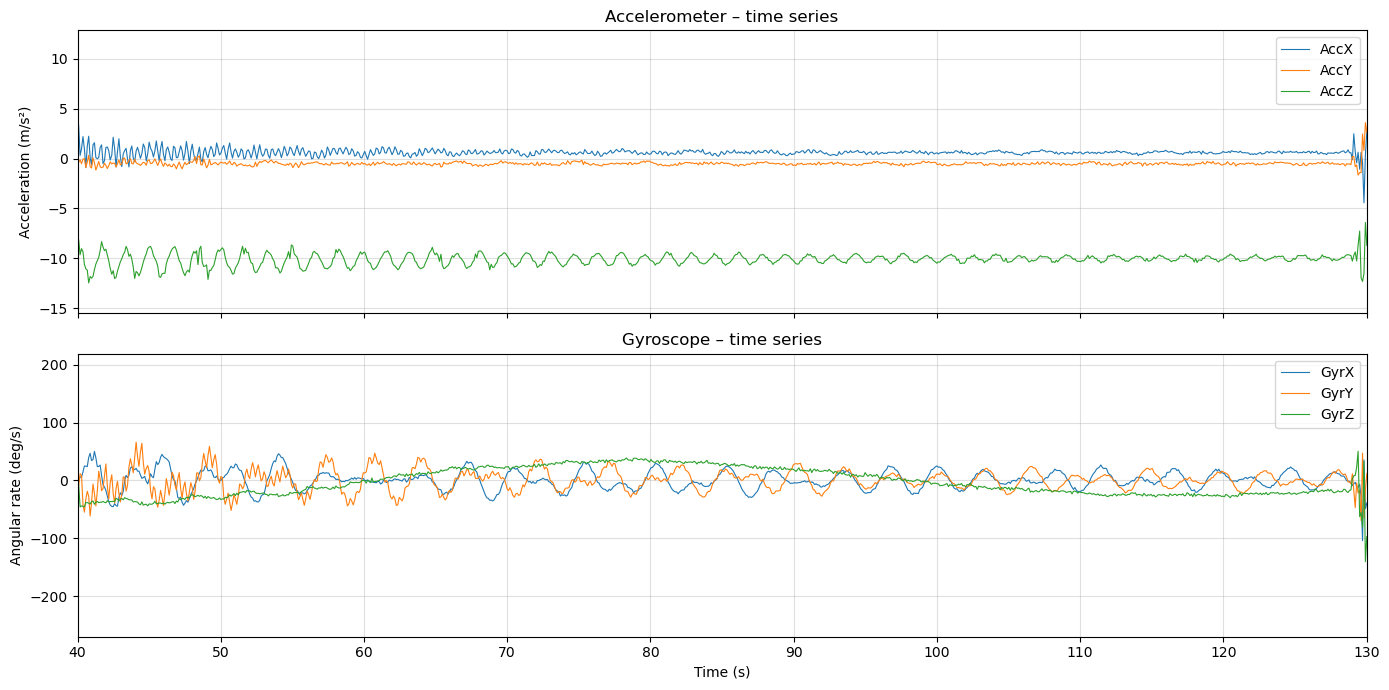

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(df['t_s'], df['AccX'], label='AccX', lw=0.8)
axes[0].plot(df['t_s'], df['AccY'], label='AccY', lw=0.8)
axes[0].plot(df['t_s'], df['AccZ'], label='AccZ', lw=0.8)
axes[0].set_ylabel('Acceleration (m/s²)')
axes[0].set_title('Accelerometer – time series')
axes[0].legend()
axes[0].set_xlim(40,130 )
axes[0].grid(True, alpha=0.4)

axes[1].plot(df['t_s'], df['GyrX'], label='GyrX', lw=0.8)
axes[1].plot(df['t_s'], df['GyrY'], label='GyrY', lw=0.8)
axes[1].plot(df['t_s'], df['GyrZ'], label='GyrZ', lw=0.8)
axes[1].set_ylabel('Angular rate (deg/s)')
axes[1].set_xlabel('Time (s)')
axes[1].set_title('Gyroscope – time series')
axes[1].legend()
axes[1].set_xlim(40,130)
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

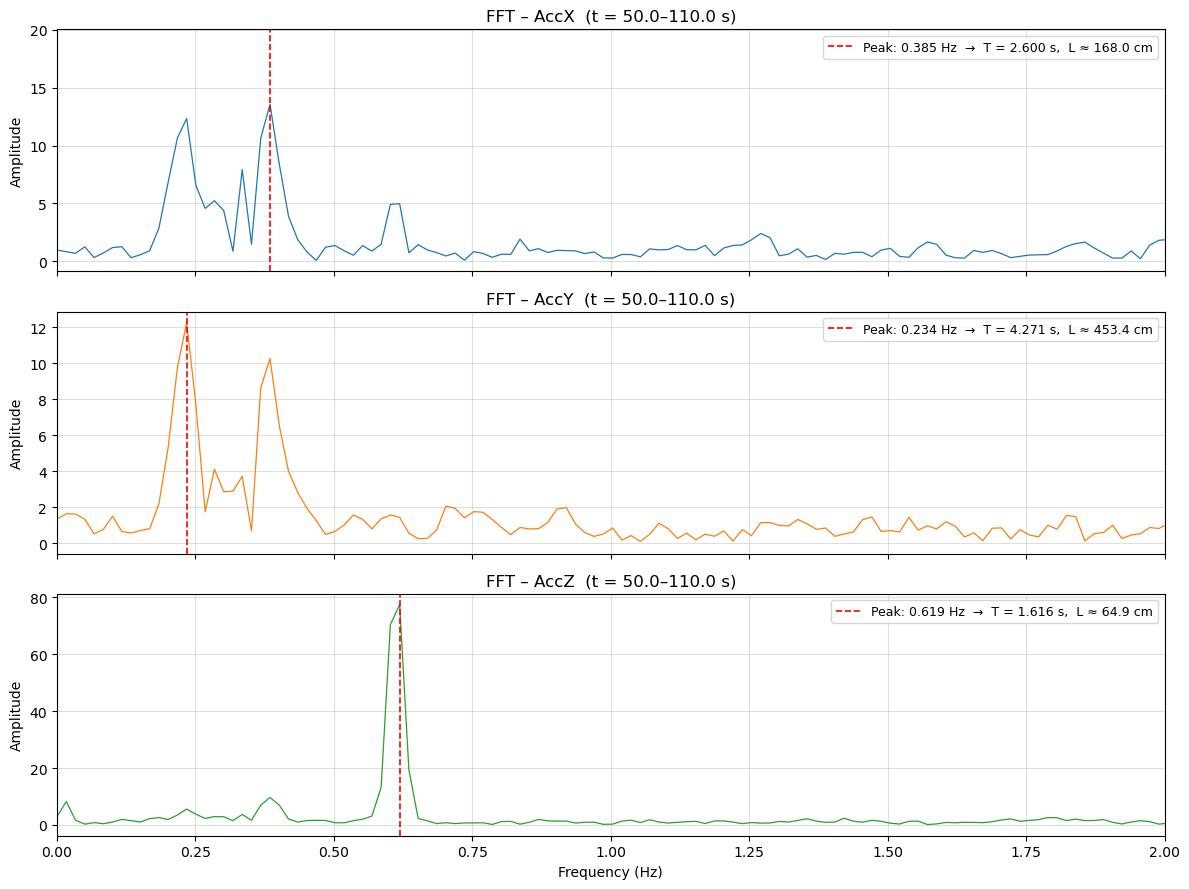

In [9]:
# ── FFT window (seconds) — adjust to focus on the swinging portion ──
T_START = 50.0
T_END   = 110.0
# ────────────────────────────────────────────────────────────────────

seg = df[(df['t_s'] >= T_START) & (df['t_s'] <= T_END)]

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

for ax, col, color in zip(axes,
                           ['AccX', 'AccY', 'AccZ'],
                           ['C0',   'C1',   'C2']):
    s = seg[col].values
    s = s - s.mean()                    # remove DC
    n = len(s)
    yf    = rfft(s * np.hanning(n))
    xf    = rfftfreq(n, 1.0 / fs)
    power = np.abs(yf)

    ax.plot(xf, power, color=color, lw=0.9)
    ax.set_ylabel('Amplitude')
    ax.set_title(f'FFT – {col}  (t = {T_START}–{T_END} s)')
    ax.set_xlim(0, 2)
    ax.grid(True, alpha=0.4)

    mask      = (xf > 0.1) & (xf < 2.0)
    peak_freq = xf[mask][np.argmax(power[mask])]
    T_peak    = 1.0 / peak_freq
    L_est     = g * (T_peak / (2 * np.pi))**2
    ax.axvline(peak_freq, color='red', linestyle='--', lw=1.2,
               label=f'Peak: {peak_freq:.3f} Hz  →  T = {T_peak:.3f} s,  L ≈ {L_est*100:.1f} cm')
    ax.legend(fontsize=9)

axes[-1].set_xlabel('Frequency (Hz)')
plt.tight_layout()
plt.show()

In [10]:
## Comparison: theoretical vs measured period

L_m      = 97 * 0.0254          # 97 in → metres
T_theory = 2 * np.pi * np.sqrt(L_m / g)

# Re-extract AccZ FFT from the same window used above
s    = seg['AccZ'].values
s    = s - s.mean()
n    = len(s)
yf   = rfft(s * np.hanning(n))
xf   = rfftfreq(n, 1.0 / fs)

mask        = (xf > 0.1) & (xf < 2.0)
f_z_peak    = xf[mask][np.argmax(np.abs(yf)[mask])]
T_pendulum  = 2.0 / f_z_peak           # AccZ runs at 2× pendulum frequency

print(f'AccZ FFT peak frequency : {f_z_peak:.3f} Hz  →  T_pendulum = 2 / {f_z_peak:.3f} = {T_pendulum:.3f} s')
print(f'Theoretical period      : {T_theory:.3f} s  (L = {L_m:.3f} m)')
print(f'Difference              : {abs(T_pendulum - T_theory):.3f} s  ({100*abs(T_pendulum - T_theory)/T_theory:.1f}%)')

AccZ FFT peak frequency : 0.619 Hz  →  T_pendulum = 2 / 0.619 = 3.232 s
Theoretical period      : 3.149 s  (L = 2.464 m)
Difference              : 0.084 s  (2.7%)


## Summary

The measured pendulum length was 97 in, which converts to:

$$L = 97 \times 0.0254 = 2.464 \text{ m}$$

For a simple pendulum, the expected period is:

$$T = 2\pi\sqrt{\frac{L}{g}} = 2\pi\sqrt{\frac{2.464}{9.81}} \approx 3.15 \text{ s}$$

Because the pendulum was rotating as it swung, the gravitational component did not project cleanly onto a single horizontal axis — instead it rotated continuously through the X–Y plane, making it difficult to isolate the pendulum frequency from AccX or AccY alone.

The clearest signal came from the **Z-axis acceleration** (along the rod). Two effects both contribute to AccZ oscillating at twice the pendulum frequency, and their relative size can be found exactly from energy conservation.

At the bottom of the swing the bob moves fastest. Energy conservation gives:

$$\frac{1}{2}mv^2 = mgL(1-\cos\theta_0) \implies a_\text{centripetal} = \frac{v^2}{L} = 2g(1-\cos\theta_0)$$

The change in the gravity projection between the bottom and the extremes is:

$$\Delta(g\cos\theta) = g(1 - \cos\theta_0)$$

The centripetal term is therefore **exactly twice** the gravity-projection term at any amplitude. At $\theta_0 = 15°$ these are approximately 0.67 m/s² and 0.34 m/s² respectively — both physically significant, but centripetal dominates.

Both effects are maximum at the bottom of the swing and minimum at the extremes, so AccZ peaks **twice per pendulum cycle** — once on each side. The dominant frequency in the AccZ spectrum is therefore:

$$f_Z = 2\,f_\text{pendulum}$$

and the true period is recovered as:

$$T_\text{pendulum} = \frac{2}{f_Z}$$

The AccZ FFT yields a measured period of 3.23 s, within 2.7% of the theoretical 3.15 s — good agreement given that the simple pendulum formula assumes a point mass and a massless rod.